In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install sqlite3

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sales_data = pd.DataFrame({
    "estado": ["CDMX","Jalisco","Nuevo León","Puebla","Yucatán","Querétaro","Guanajuato"],
    "ingresos": [520000, 430000, 390000, 310000, 260000, 280000, 300000],
    "costo": [350000, 300000, 270000, 210000, 180000, 190000, 200000],
    "clientes": [1200, 980, 860, 720, 610, 650, 700],
    "mes": ["2024-01"]*7
})

sales_data

,estado,ingresos,costo,clientes,mes
0,CDMX,520000,350000,1200,2024-01
1,Jalisco,430000,300000,980,2024-01
2,Nuevo León,390000,270000,860,2024-01
3,Puebla,310000,210000,720,2024-01
4,Yucatán,260000,180000,610,2024-01
5,Querétaro,280000,190000,650,2024-01
6,Guanajuato,300000,200000,700,2024-01


In [ ]:
sales_data["ganancia"] = sales_data["ingresos"] - sales_data["costo"]
sales_data["ticket_promedio"] = sales_data["ingresos"] / sales_data["clientes"]
sales_data["margen"] = sales_data["ganancia"] / sales_data["ingresos"]

sales_data

,estado,ingresos,costo,clientes,mes,ganancia,ticket_promedio,margen
0,CDMX,520000,350000,1200,2024-01,170000,433.333333,0.326923
1,Jalisco,430000,300000,980,2024-01,130000,438.775510,0.302326
2,Nuevo León,390000,270000,860,2024-01,120000,453.488372,0.307692
3,Puebla,310000,210000,720,2024-01,100000,430.555556,0.322581
4,Yucatán,260000,180000,610,2024-01,80000,426.229508,0.307692
5,Querétaro,280000,190000,650,2024-01,90000,430.769231,0.321429
6,Guanajuato,300000,200000,700,2024-01,100000,428.571429,0.333333


In [ ]:
sales_data.columns

Index(['estado', 'ingresos', 'costo', 'clientes', 'mes', 'ganancia',
       'ticket_promedio', 'margen'],
      dtype='object')

In [ ]:
# Verificación simple de calidad de datos
sales_data["margen_valido"] = sales_data["margen"].apply(
    lambda x: "ok" if 0 <= x <= 1 else "revisar"
)

sales_data

,estado,ingresos,costo,clientes,mes,ganancia,ticket_promedio,margen,margen_valido
0,CDMX,520000,350000,1200,2024-01,170000,433.333333,0.326923,ok
1,Jalisco,430000,300000,980,2024-01,130000,438.775510,0.302326,ok
2,Nuevo León,390000,270000,860,2024-01,120000,453.488372,0.307692,ok
3,Puebla,310000,210000,720,2024-01,100000,430.555556,0.322581,ok
4,Yucatán,260000,180000,610,2024-01,80000,426.229508,0.307692,ok
5,Querétaro,280000,190000,650,2024-01,90000,430.769231,0.321429,ok
6,Guanajuato,300000,200000,700,2024-01,100000,428.571429,0.333333,ok


In [ ]:
targets = pd.DataFrame({
    "estado": ["CDMX","Jalisco","Nuevo León","Puebla","Yucatán","Querétaro","Guanajuato"],
    "objetivo_ingresos": [500000,420000,400000,300000,250000,270000,290000]
})

targets

,estado,objetivo_ingresos
0,CDMX,500000
1,Jalisco,420000
2,Nuevo León,400000
3,Puebla,300000
4,Yucatán,250000
5,Querétaro,270000
6,Guanajuato,290000


In [ ]:
business = pd.merge(sales_data, targets, on="estado", how="left")

business["logro"] = business["ingresos"] / business["objetivo_ingresos"]

business

,estado,ingresos,costo,clientes,mes,ganancia,ticket_promedio,margen,margen_valido,objetivo_ingresos,logro
0,CDMX,520000,350000,1200,2024-01,170000,433.333333,0.326923,ok,500000,1.040000
1,Jalisco,430000,300000,980,2024-01,130000,438.775510,0.302326,ok,420000,1.023810
2,Nuevo León,390000,270000,860,2024-01,120000,453.488372,0.307692,ok,400000,0.975000
3,Puebla,310000,210000,720,2024-01,100000,430.555556,0.322581,ok,300000,1.033333
4,Yucatán,260000,180000,610,2024-01,80000,426.229508,0.307692,ok,250000,1.040000
5,Querétaro,280000,190000,650,2024-01,90000,430.769231,0.321429,ok,270000,1.037037
6,Guanajuato,300000,200000,700,2024-01,100000,428.571429,0.333333,ok,290000,1.034483


In [ ]:
summary = business.groupby("mes").agg({
    "ingresos":"sum",
    "ganancia":"sum",
    "clientes":"sum"
})

summary

,ingresos,ganancia,clientes
mes,,,
2024-01,2490000,790000,5720


Text(0.5, 1.0, 'Ganancia por Estado - MexRetail')

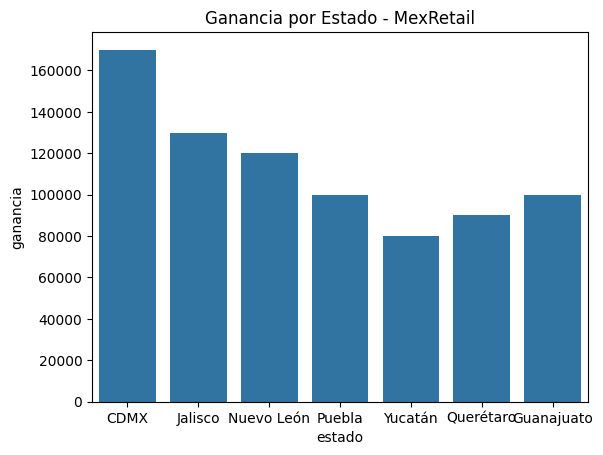

In [ ]:
sns.barplot(data=business, x="estado", y="ganancia")
plt.title("Ganancia por Estado - MexRetail")

In [ ]:
def clasificar_rendimiento(logro):
    if logro >= 1:
        return "por encima del objetivo"
    elif logro >= 0.9:
        return "cerca del objetivo"
    else:
        return "por debajo del objetivo"

business["rendimiento"] = business["logro"].apply(clasificar_rendimiento)

business

,estado,ingresos,costo,clientes,mes,ganancia,ticket_promedio,margen,margen_valido,objetivo_ingresos,logro,rendimiento
0,CDMX,520000,350000,1200,2024-01,170000,433.333333,0.326923,ok,500000,1.040000,por encima del objetivo
1,Jalisco,430000,300000,980,2024-01,130000,438.775510,0.302326,ok,420000,1.023810,por encima del objetivo
2,Nuevo León,390000,270000,860,2024-01,120000,453.488372,0.307692,ok,400000,0.975000,cerca del objetivo
3,Puebla,310000,210000,720,2024-01,100000,430.555556,0.322581,ok,300000,1.033333,por encima del objetivo
4,Yucatán,260000,180000,610,2024-01,80000,426.229508,0.307692,ok,250000,1.040000,por encima del objetivo
5,Querétaro,280000,190000,650,2024-01,90000,430.769231,0.321429,ok,270000,1.037037,por encima del objetivo
6,Guanajuato,300000,200000,700,2024-01,100000,428.571429,0.333333,ok,290000,1.034483,por encima del objetivo


In [ ]:
def kpis_negocio(df):
    return {
        "ingresos_totales": df["ingresos"].sum(),
        "ganancia_total": df["ganancia"].sum(),
        "margen_global": df["ganancia"].sum() / df["ingresos"].sum()
    }

kpis_negocio(business)

{'ingresos_totales': np.int64(2490000),
 'ganancia_total': np.int64(790000),
 'margen_global': np.float64(0.3172690763052209)}

In [ ]:
import sqlite3

con = sqlite3.connect("mex_minorista.db")
business.to_sql("ventas", con, if_exists="replace", index=False)

pd.read_sql("SELECT estado, ingresos, ganancia FROM ventas", con)

,estado,ingresos,ganancia
0,CDMX,520000,170000
1,Jalisco,430000,130000
2,Nuevo León,390000,120000
3,Puebla,310000,100000
4,Yucatán,260000,80000
5,Querétaro,280000,90000
6,Guanajuato,300000,100000
